In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve)
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


<a id="4"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">Data Preprocessing</div>

In [7]:
df.shape

(768, 9)

In [8]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Finding Missing Data</b></span>

In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Finding and Handling Outliers</b></span>

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

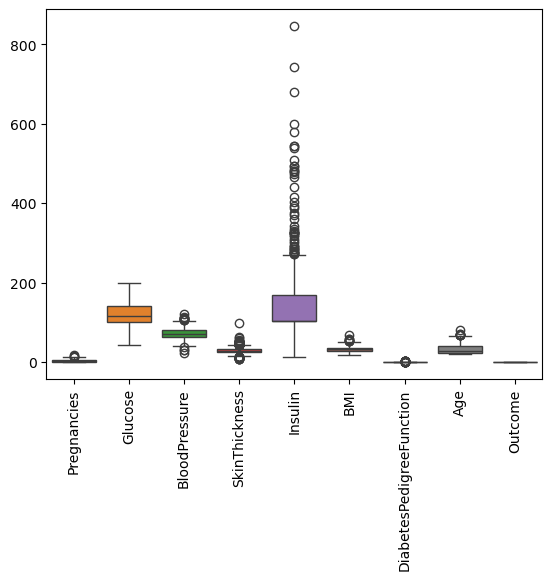

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df)
plt.xticks(rotation=90)

In [14]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df < lower) | (df > upper)).sum()
print(outlier_count)

Pregnancies                  4
Glucose                      0
BloodPressure               14
SkinThickness               87
Insulin                     51
BMI                          8
DiabetesPedigreeFunction    29
Age                          9
Outcome                      0
dtype: int64


Q1: 1.0
Q3: 6.0
IQR: 5.0
lower_bound: -6.5
upper_bound: 13.5
Number of outliers: 4


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

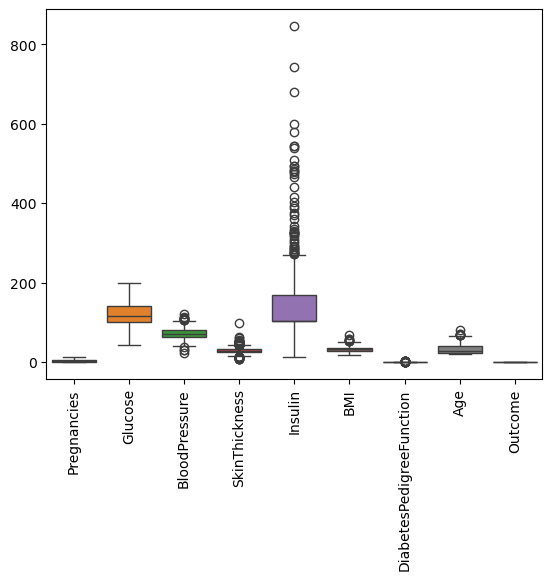

In [15]:
#Remove outliers
Q1=np.percentile(df['Pregnancies'],25)
Q3=np.percentile(df['Pregnancies'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['Pregnancies']<lower_bound)|(df['Pregnancies']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['Pregnancies']=df['Pregnancies'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 64.0
Q3: 80.0
IQR: 16.0
lower_bound: 40.0
upper_bound: 104.0
Number of outliers: 14


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

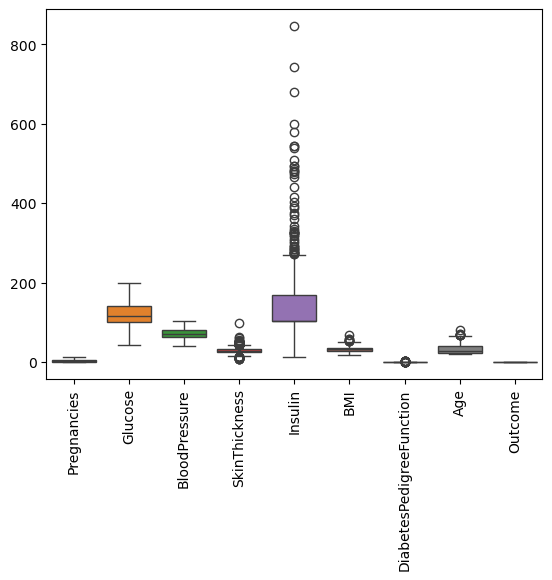

In [16]:
#Remove outliers
Q1=np.percentile(df['BloodPressure'],25)
Q3=np.percentile(df['BloodPressure'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['BloodPressure']<lower_bound)|(df['BloodPressure']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['BloodPressure']=df['BloodPressure'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 25.0
Q3: 32.0
IQR: 7.0
lower_bound: 14.5
upper_bound: 42.5
Number of outliers: 87


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

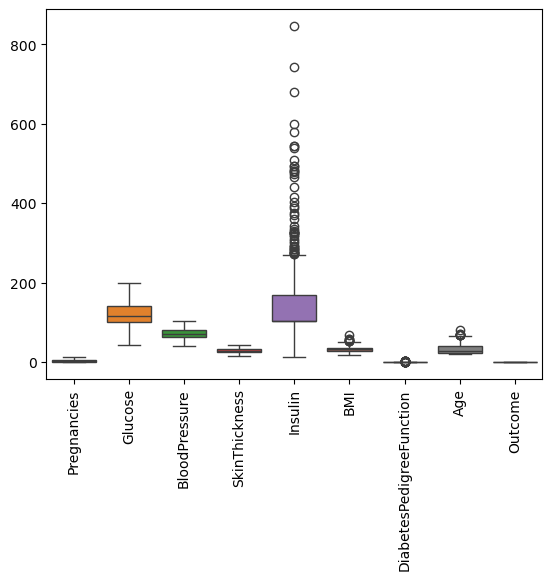

In [17]:
#Remove outliers
Q1=np.percentile(df['SkinThickness'],25)
Q3=np.percentile(df['SkinThickness'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['SkinThickness']<lower_bound)|(df['SkinThickness']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['SkinThickness']=df['SkinThickness'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 102.5
Q3: 169.5
IQR: 67.0
lower_bound: 2.0
upper_bound: 270.0
Number of outliers: 51


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

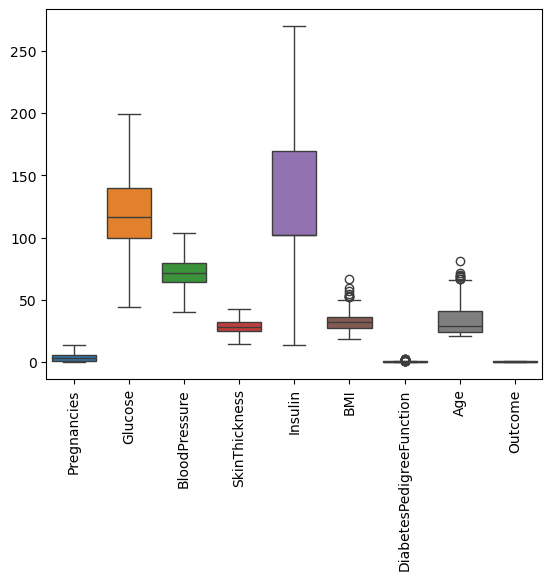

In [18]:
#Remove outliers
Q1=np.percentile(df['Insulin'],25)
Q3=np.percentile(df['Insulin'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['Insulin']<lower_bound)|(df['Insulin']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['Insulin']=df['Insulin'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 27.5
Q3: 36.6
IQR: 9.100000000000001
lower_bound: 13.849999999999998
upper_bound: 50.25
Number of outliers: 8


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

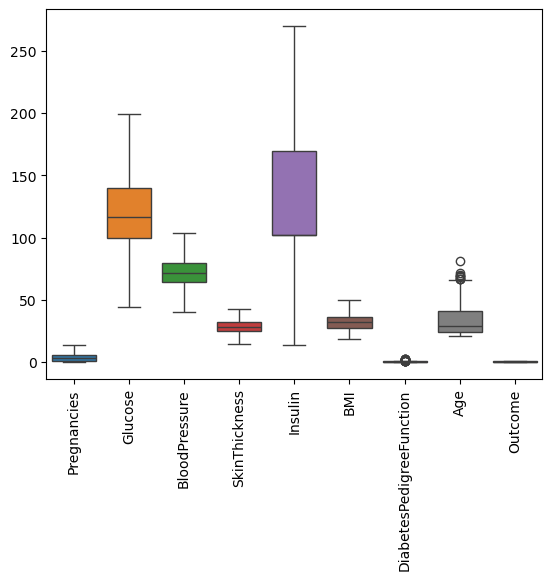

In [19]:
#Remove outliers
Q1=np.percentile(df['BMI'],25)
Q3=np.percentile(df['BMI'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['BMI']<lower_bound)|(df['BMI']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['BMI']=df['BMI'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 0.24375
Q3: 0.62625
IQR: 0.38249999999999995
lower_bound: -0.32999999999999996
upper_bound: 1.2
Number of outliers: 29


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

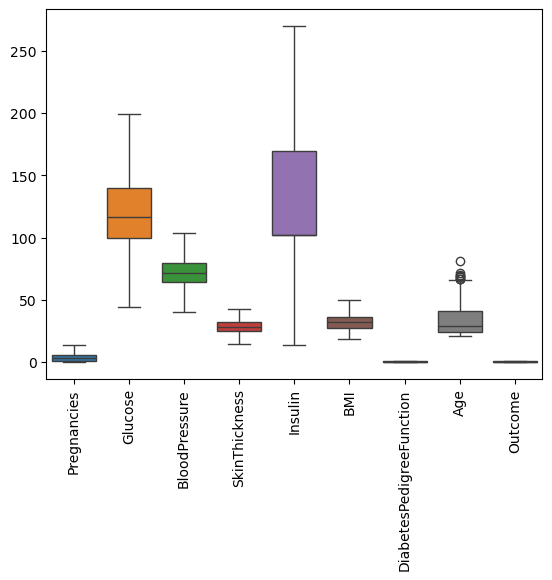

In [20]:
#Remove outliers
Q1=np.percentile(df['DiabetesPedigreeFunction'],25)
Q3=np.percentile(df['DiabetesPedigreeFunction'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['DiabetesPedigreeFunction']<lower_bound)|(df['DiabetesPedigreeFunction']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['DiabetesPedigreeFunction']=df['DiabetesPedigreeFunction'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 24.0
Q3: 41.0
IQR: 17.0
lower_bound: -1.5
upper_bound: 66.5
Number of outliers: 9


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

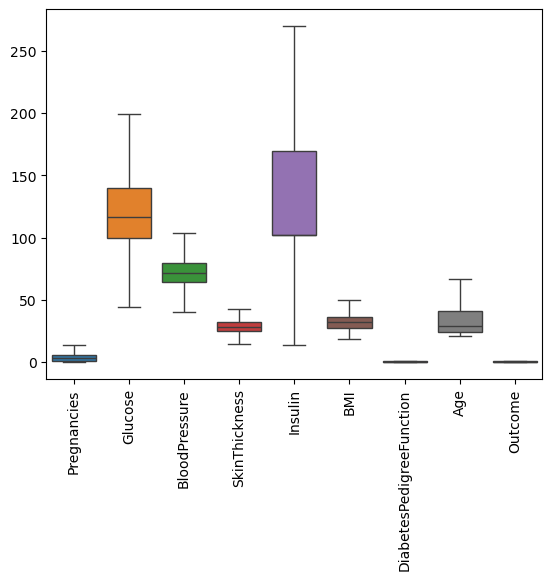

In [21]:
#Remove outliers
Q1=np.percentile(df['Age'],25)
Q3=np.percentile(df['Age'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['Age']<lower_bound)|(df['Age']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['Age']=df['Age'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

In [22]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df < lower) | (df > upper)).sum()
print(outlier_count)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Feature Selection</b></span>

In [23]:
X = df.drop('Outcome', axis = 1)
y = df['Outcome']
print("FEATURES")
X.head()

FEATURES


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148,72.0,35.0,169.5,33.6,0.627,50.0
1,1.0,85,66.0,29.0,102.5,26.6,0.351,31.0
2,8.0,183,64.0,32.0,169.5,23.3,0.672,32.0
3,1.0,89,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137,40.0,35.0,168.0,43.1,1.200,33.0


In [24]:
print("TARGET")
y.head()

TARGET


0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Splitting The Data Set</b></span>

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Display the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Feature Scaling</b></span>

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<a id="4"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">Data Exploration</div>

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Visualization of Attributes</b></span>

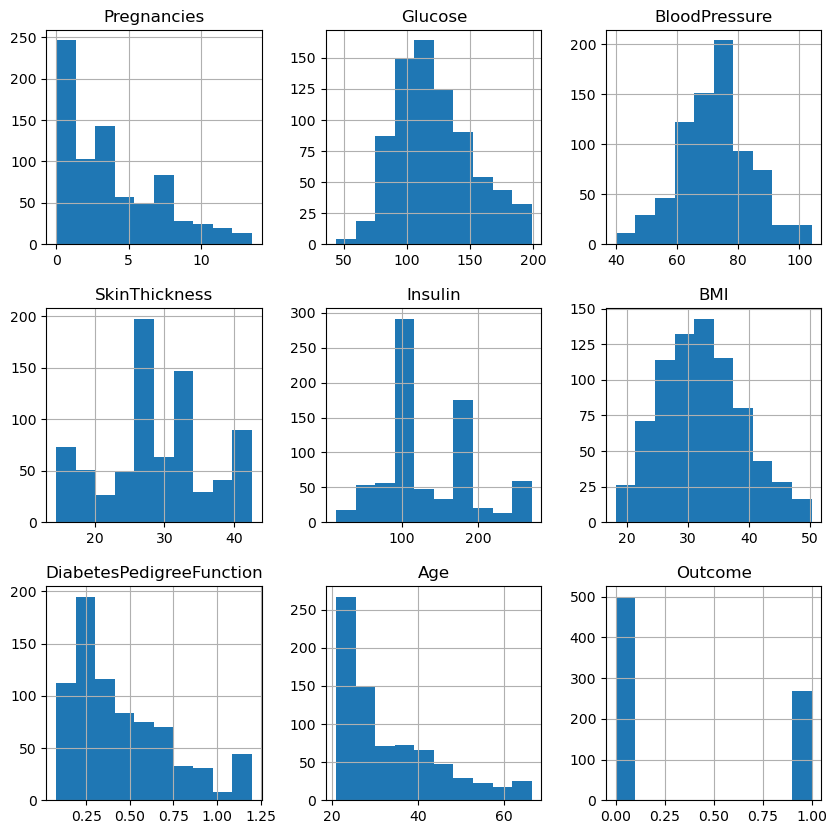

In [27]:
df.hist(figsize = (10,10))
plt.show()

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Box Plot</b></span>

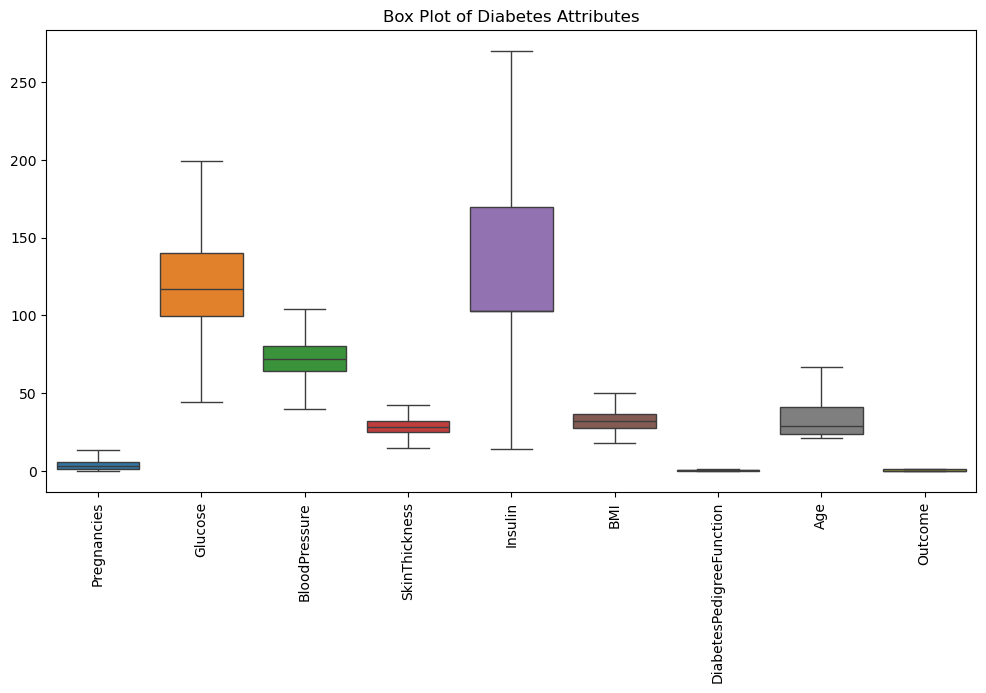

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df)

plt.title("Box Plot of Diabetes Attributes")
plt.xticks(rotation=90)
plt.show()

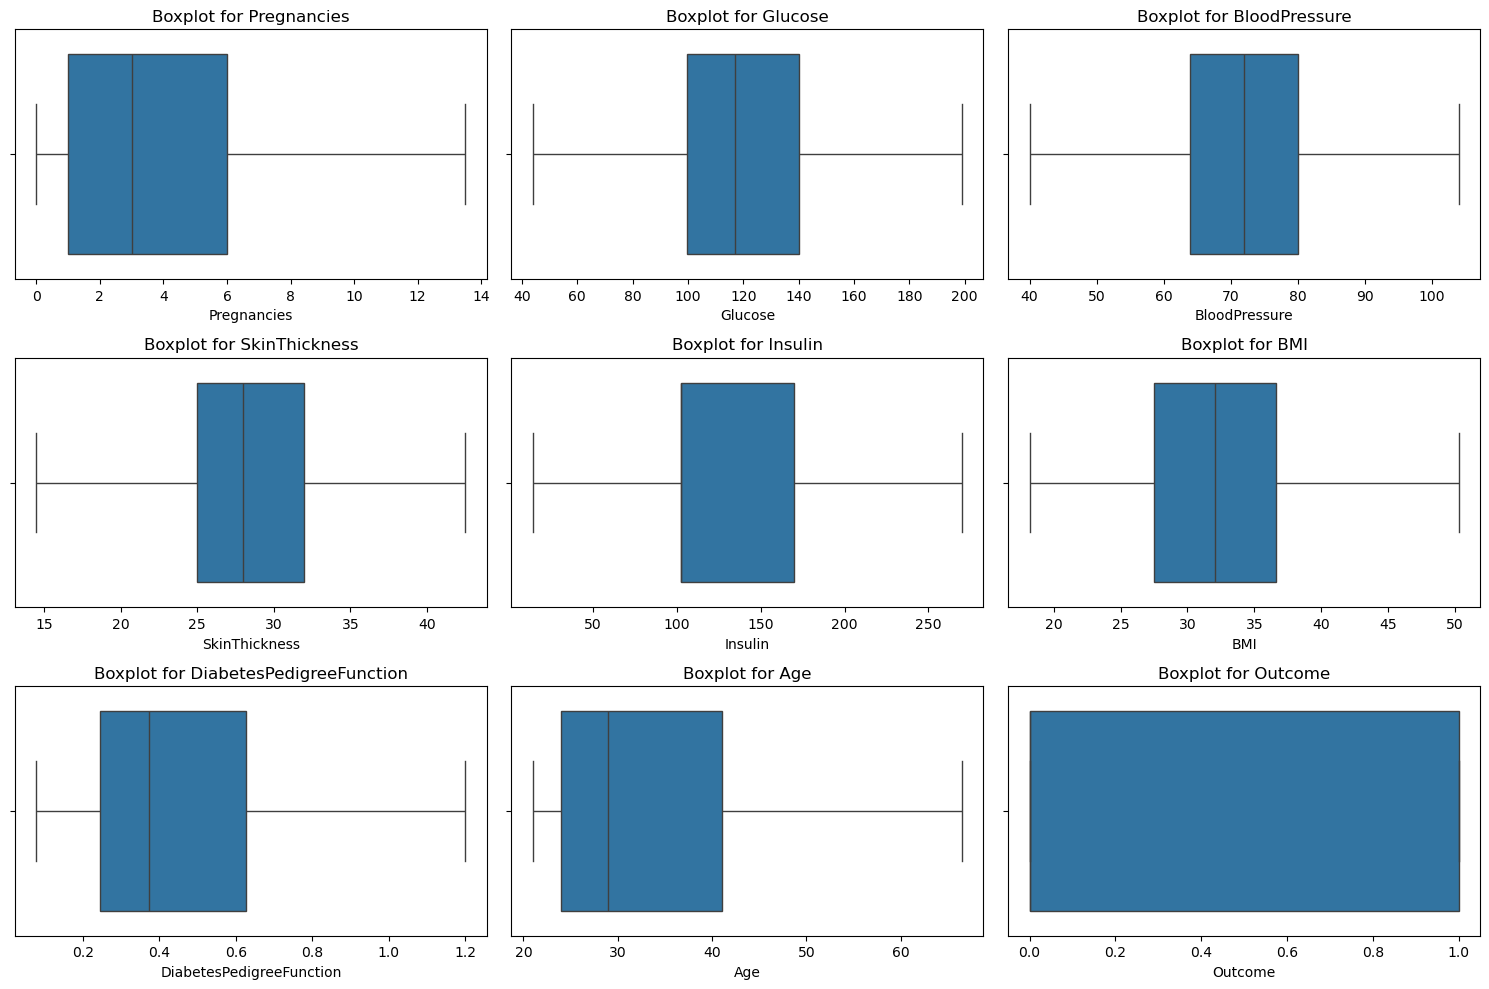

In [31]:
num_rows, num_cols = 3, 3

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten the axes for easier iteration
axes = axes.flatten()

# Loop through numeric columns and create boxplots
for i, column in enumerate(df.columns):
    sns.boxplot(data=df, x=column, ax=axes[i])
    axes[i].set_title(f'Boxplot for {column}')

# Remove any remaining empty subplots
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Correlation</b></span>

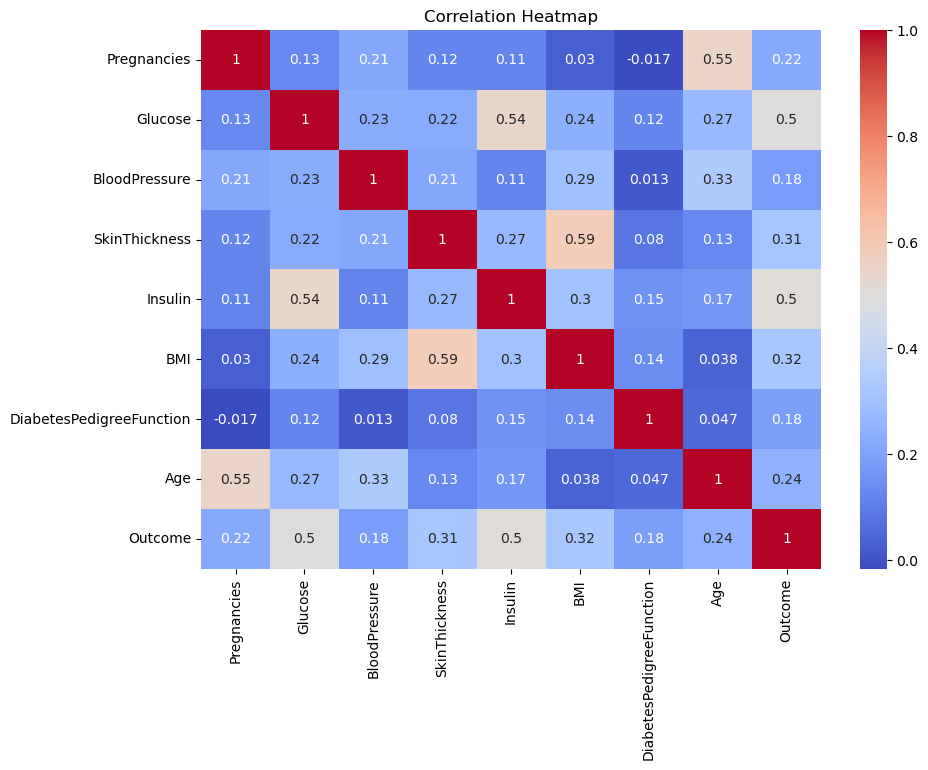

In [32]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Pair Plot</b></span>

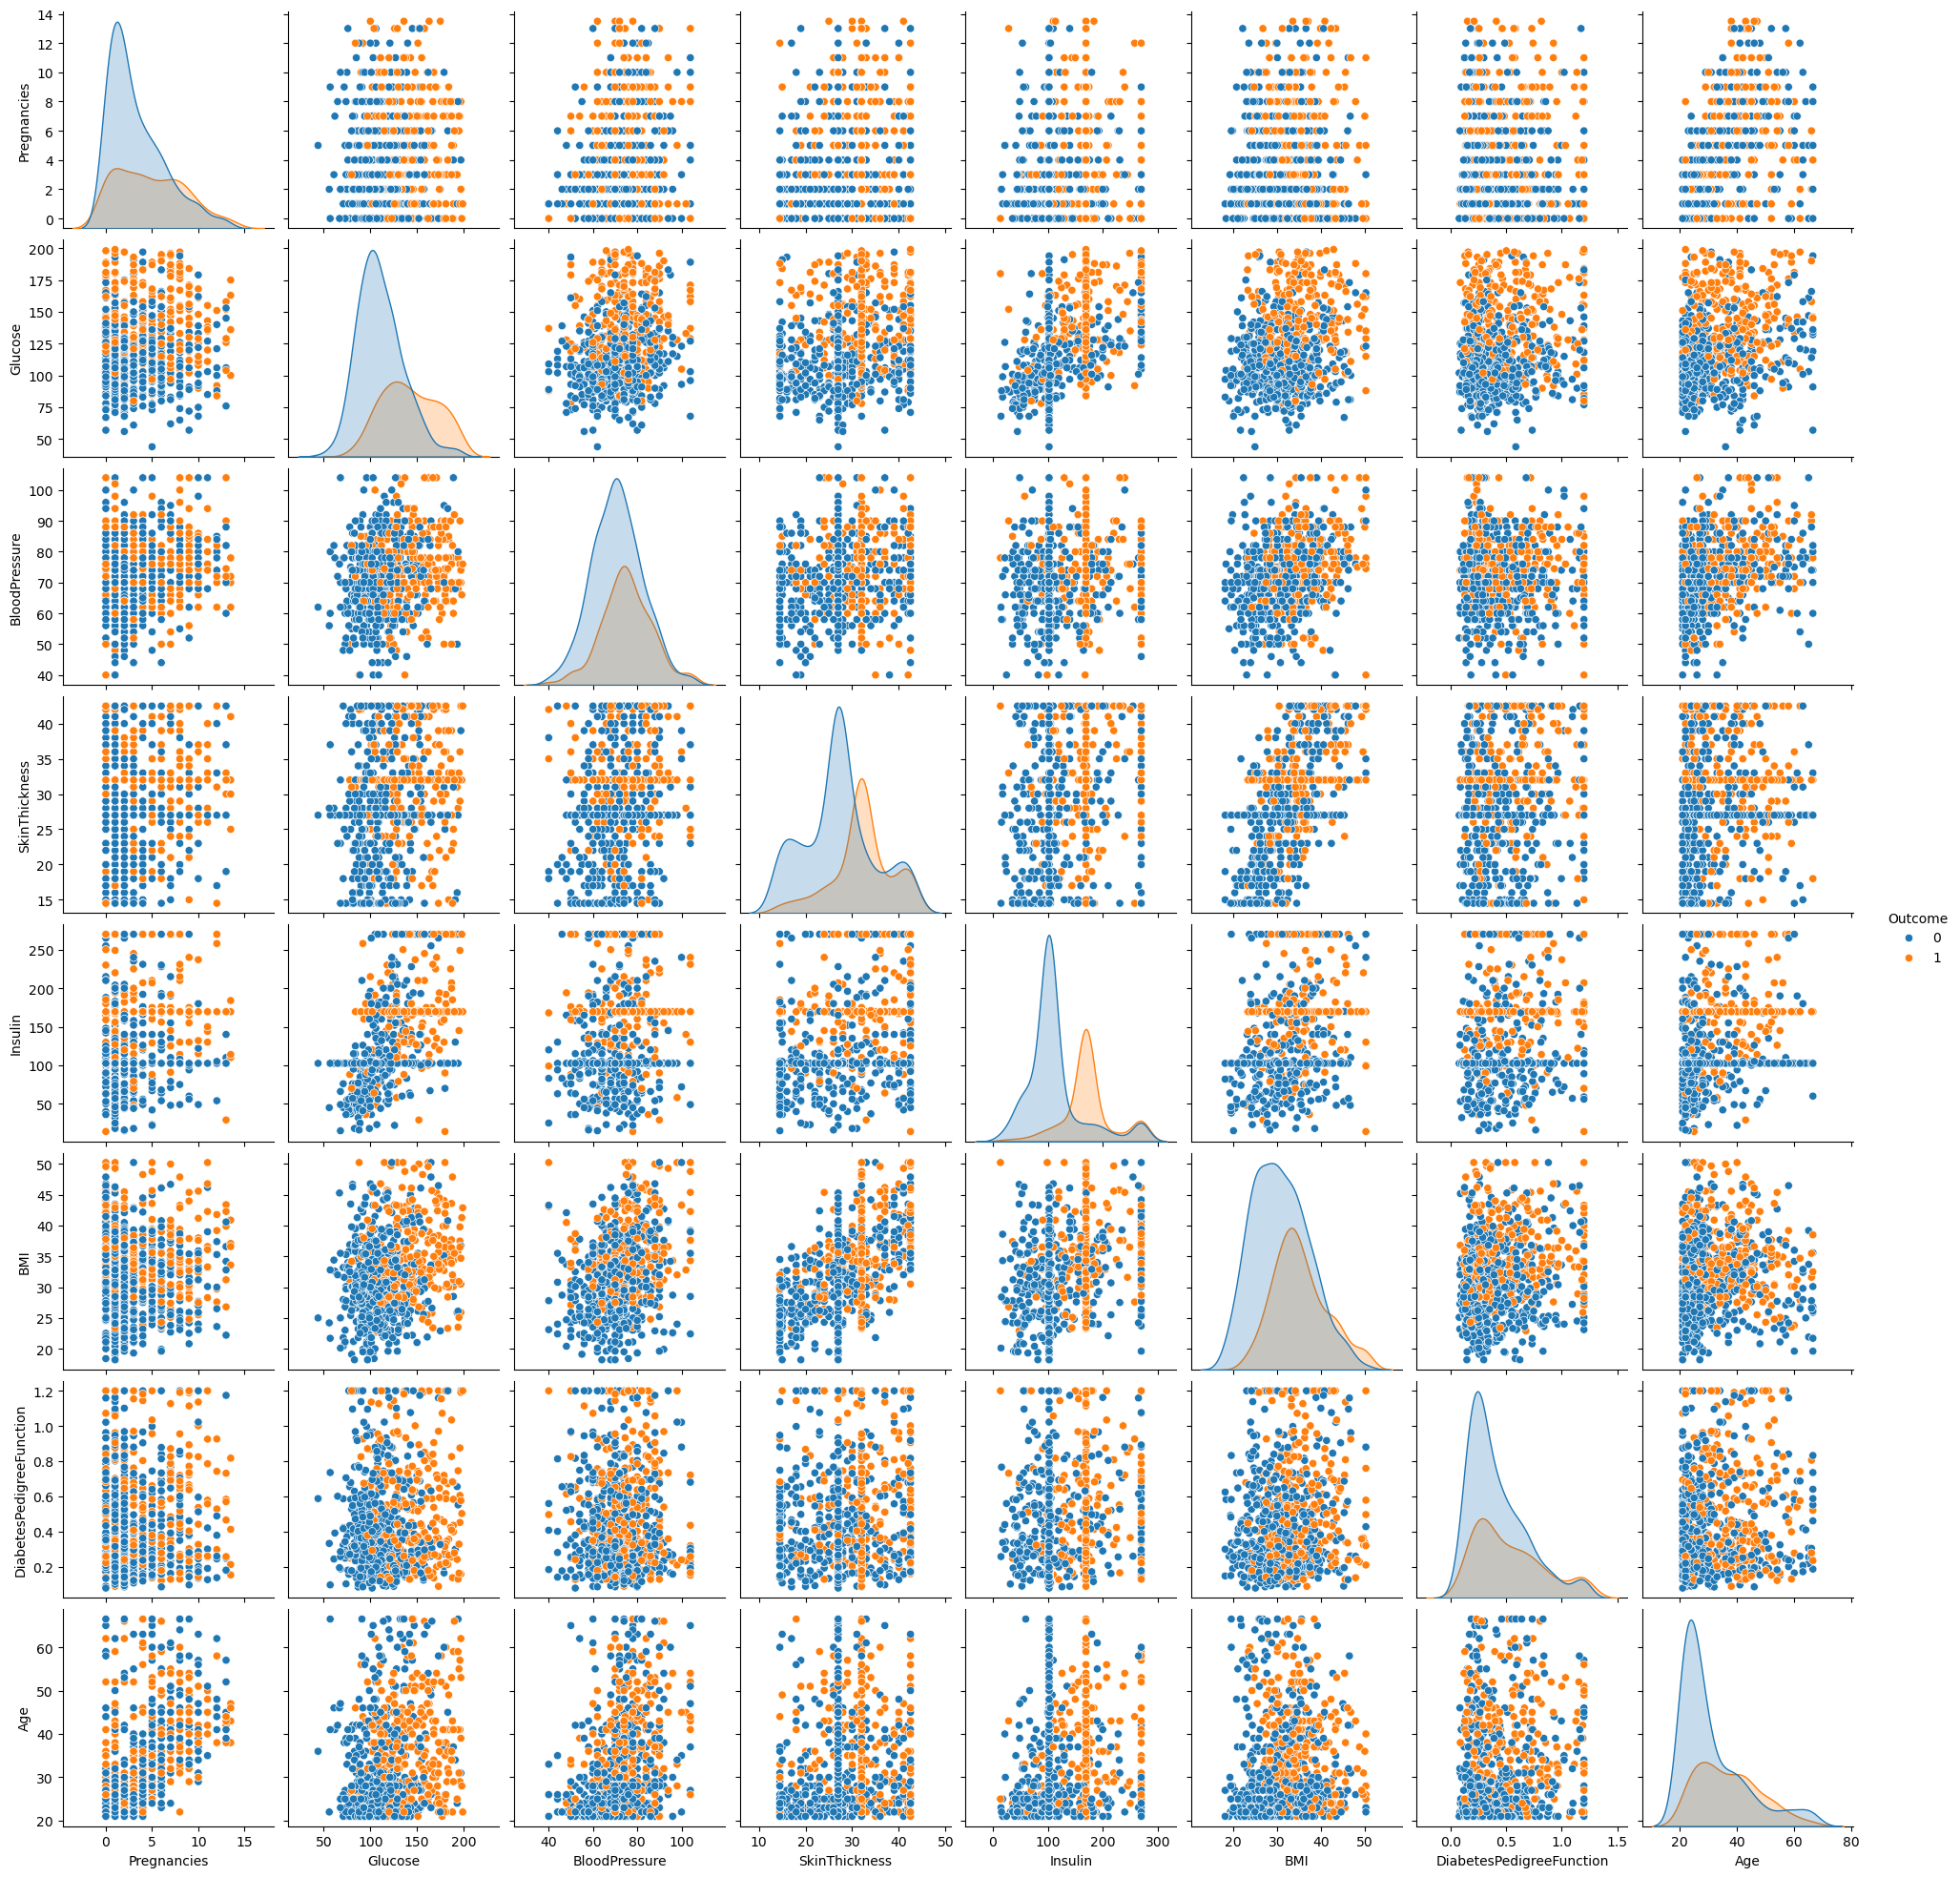

In [33]:
sns.pairplot(data = df, hue = 'Outcome' )
plt.show()

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Feature vs Outcome</b></span>

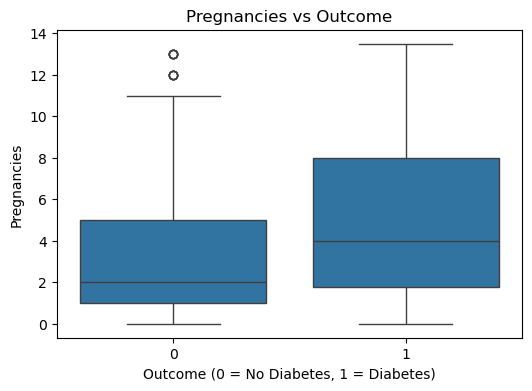

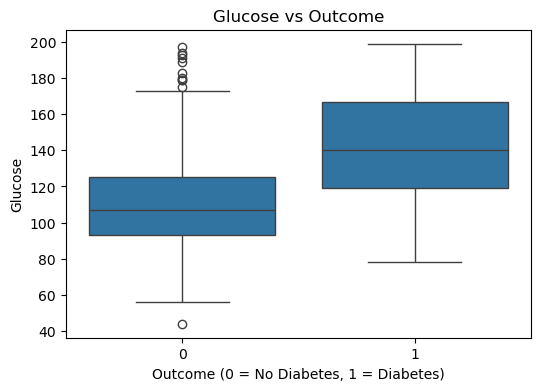

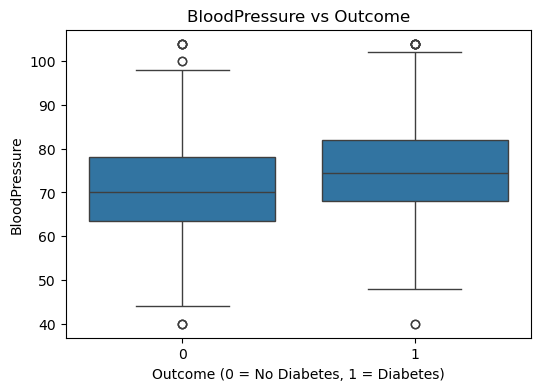

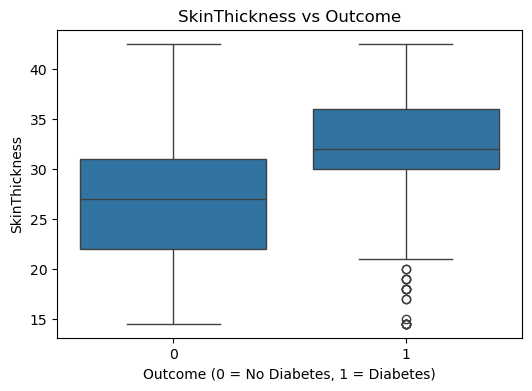

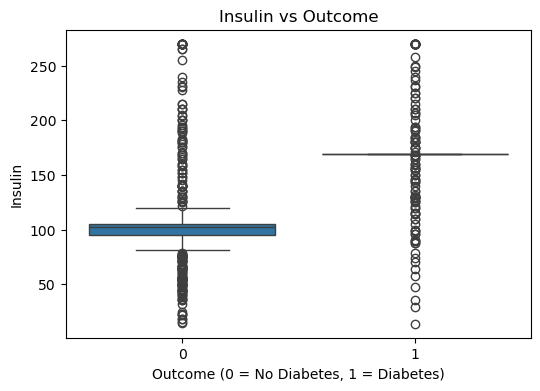

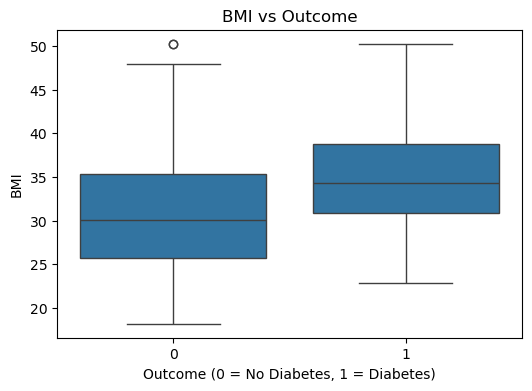

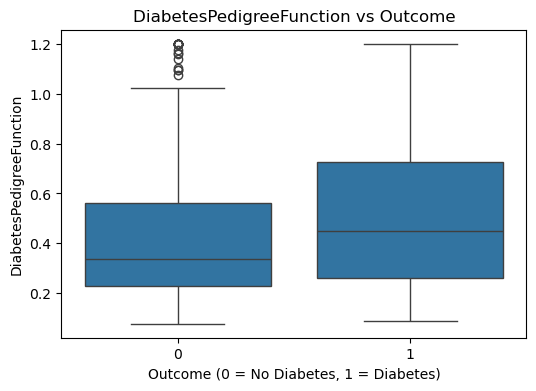

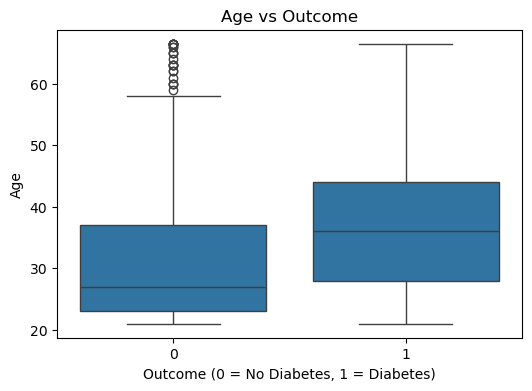

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Outcome", y=feature, data=df)
    plt.title(f"{feature} vs Outcome")
    plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
    plt.ylabel(feature)
    plt.show()

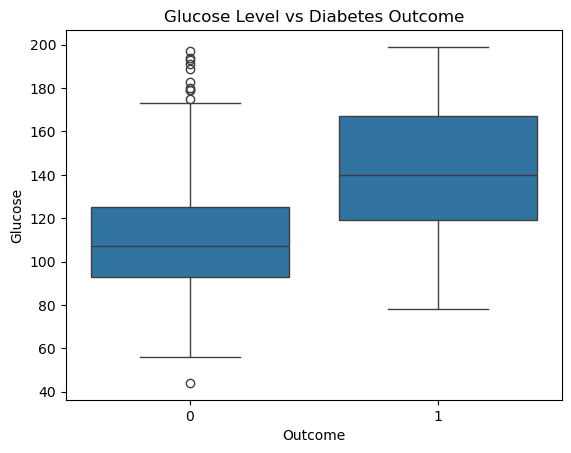

In [35]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose Level vs Diabetes Outcome")
plt.show()

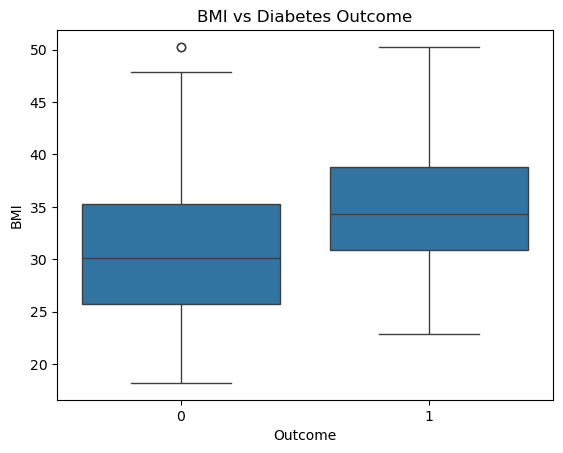

In [36]:
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI vs Diabetes Outcome")
plt.show()

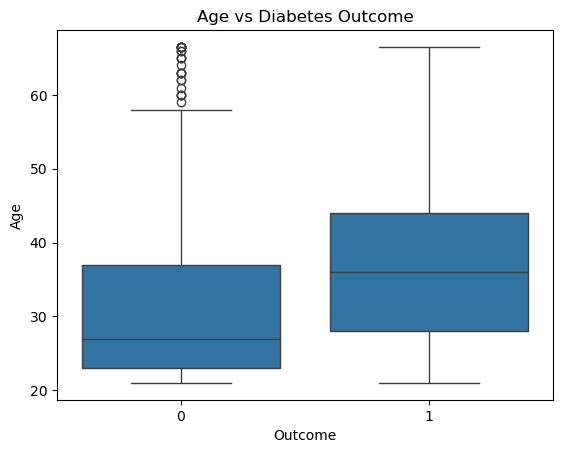

In [37]:
sns.boxplot(x='Outcome', y='Age', data=df)
plt.title("Age vs Diabetes Outcome")
plt.show()

<a id="5"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">Machine Learning models</div>

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Logistic Regression</b></span>

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8051948051948052
Confusion Matrix:
 [[84 15]
 [15 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85        99
           1       0.73      0.73      0.73        55

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154



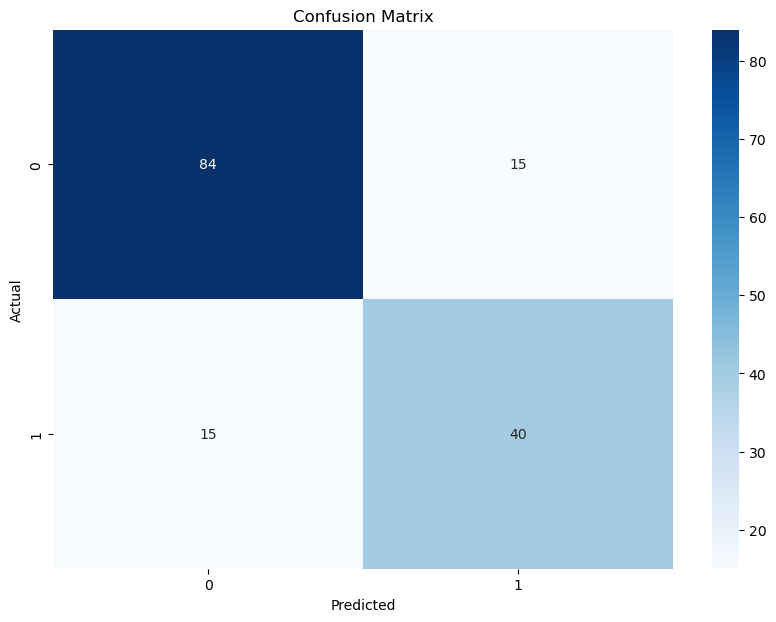

In [40]:
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
auc=roc_auc_score(y_test,y_prob)
print("ROC-AUC:",auc)

ROC-AUC: 0.8738292011019283


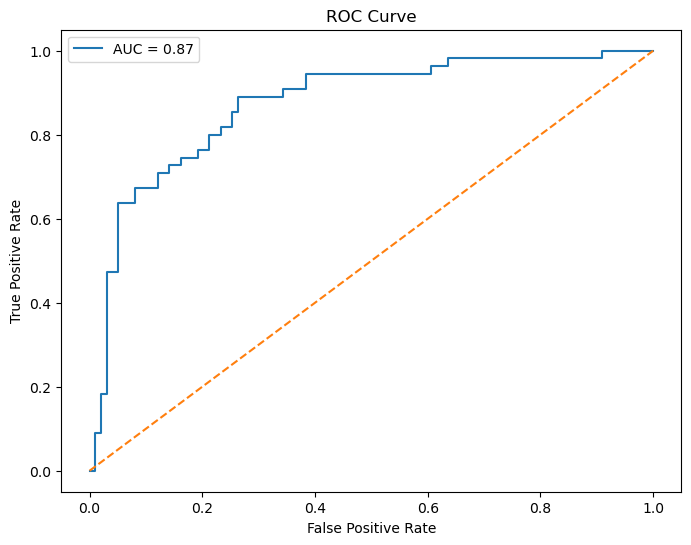

ROC-AUC: 0.8738292011019283


In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of class 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", auc)

In [46]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print("coefficients:\n",coefficients)

coefficients:
                     Feature  Coefficient
1                   Glucose     0.784716
4                   Insulin     0.758566
3             SkinThickness     0.427797
7                       Age     0.427135
5                       BMI     0.348936
6  DiabetesPedigreeFunction     0.209489
0               Pregnancies     0.203521
2             BloodPressure    -0.098898


<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Decision Tree</b></span>

In [49]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
y_pred_dt = dt_model.predict(X_test)

In [51]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)


Decision Tree Accuracy: 0.8246753246753247


In [52]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nConfusion Matrix:")
print(cm_dt)


Confusion Matrix:
[[83 16]
 [11 44]]


In [53]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        99
           1       0.73      0.80      0.77        55

    accuracy                           0.82       154
   macro avg       0.81      0.82      0.81       154
weighted avg       0.83      0.82      0.83       154



In [54]:
importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance_dt = importance_dt.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance_dt)


Feature Importance:
                    Feature  Importance
4                   Insulin    0.556449
7                       Age    0.095088
1                   Glucose    0.084697
3             SkinThickness    0.070595
5                       BMI    0.068352
2             BloodPressure    0.060483
6  DiabetesPedigreeFunction    0.035380
0               Pregnancies    0.028957


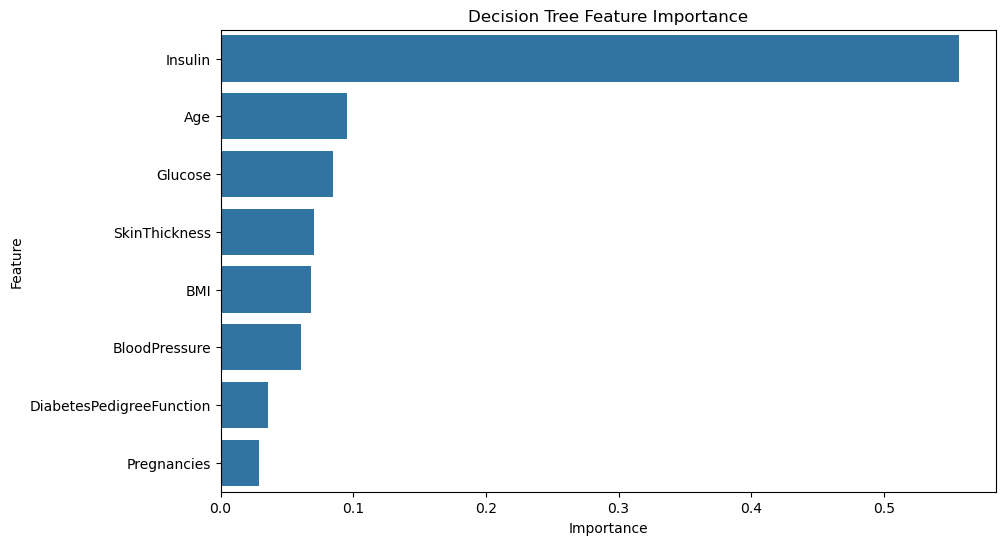

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_dt
)

plt.title("Decision Tree Feature Importance")
plt.show()

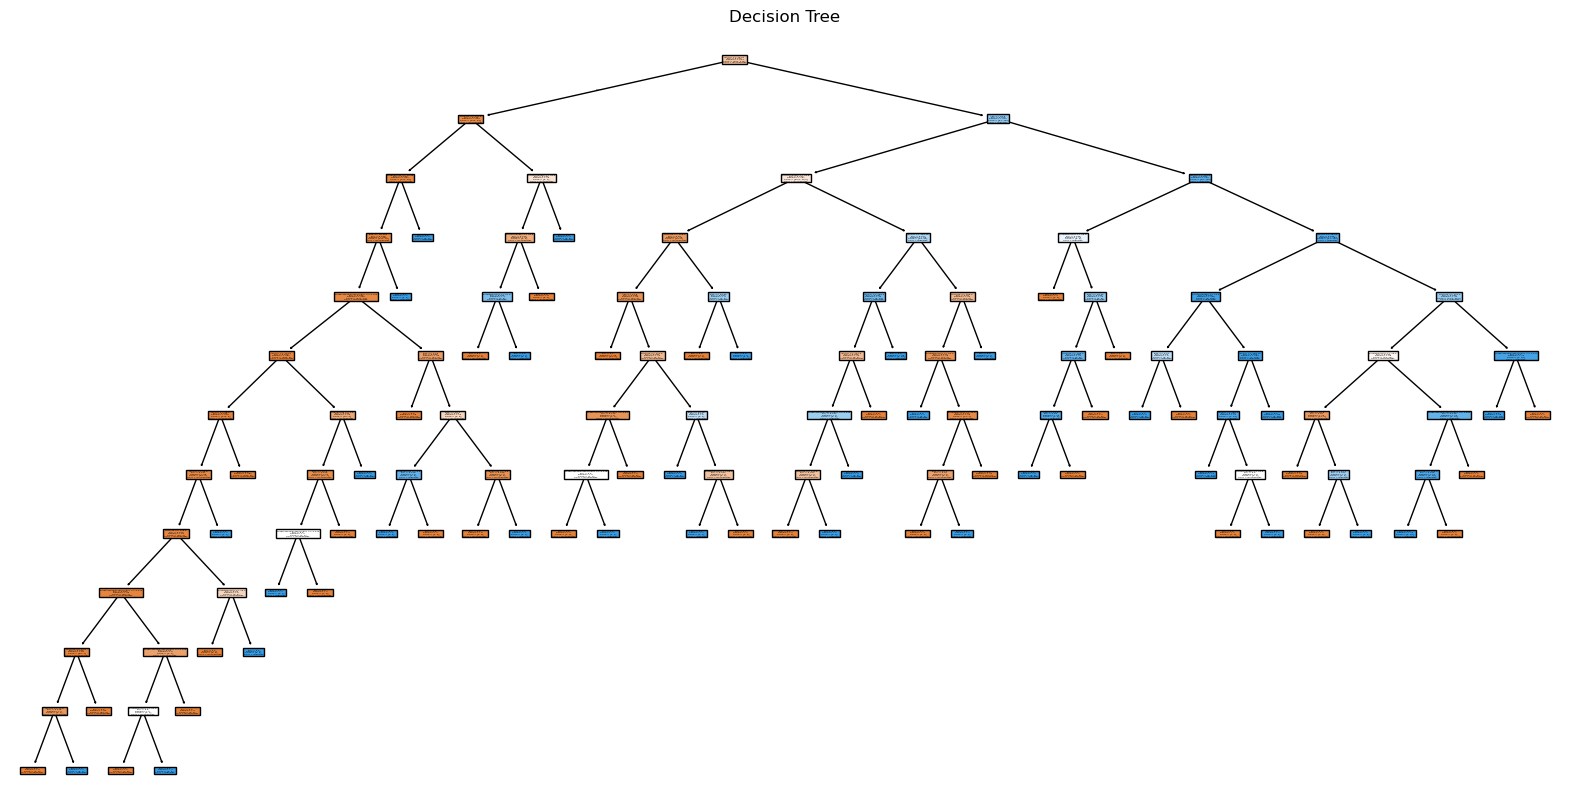

In [56]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)

plt.title("Decision Tree")
plt.show()

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Pruned Decision Tree Model
dt_pruned = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Train Model
dt_pruned.fit(X_train, y_train)

# Prediction
y_pred_pruned = dt_pruned.predict(X_test)

# Accuracy
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)

print("Pruned Decision Tree Accuracy:", accuracy_pruned)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_pruned))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned))

Pruned Decision Tree Accuracy: 0.8506493506493507

Confusion Matrix:
[[84 15]
 [ 8 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        99
           1       0.76      0.85      0.80        55

    accuracy                           0.85       154
   macro avg       0.84      0.85      0.84       154
weighted avg       0.86      0.85      0.85       154



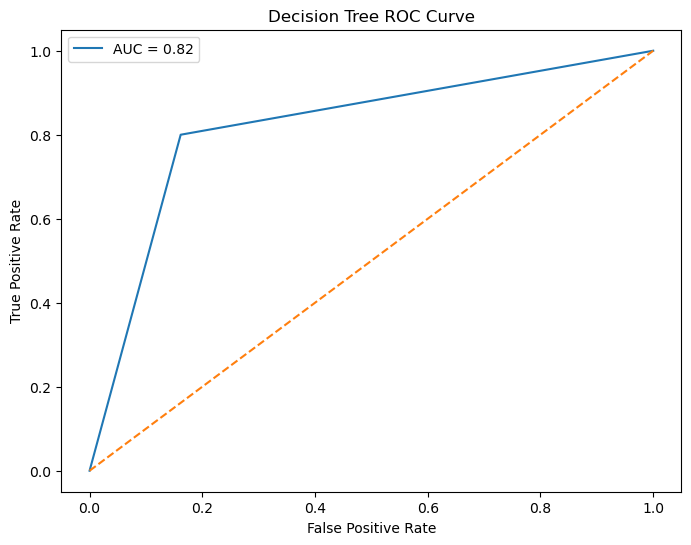

Decision Tree ROC-AUC: 0.8191919191919191


In [58]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability prediction
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# ROC values
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

# AUC
auc_dt = roc_auc_score(y_test, y_prob_dt)

# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

print("Decision Tree ROC-AUC:", auc_dt)

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>KNN</b></span>

In [60]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [62]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8701298701298701

Confusion Matrix:
[[87 12]
 [ 8 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        99
           1       0.80      0.85      0.82        55

    accuracy                           0.87       154
   macro avg       0.86      0.87      0.86       154
weighted avg       0.87      0.87      0.87       154



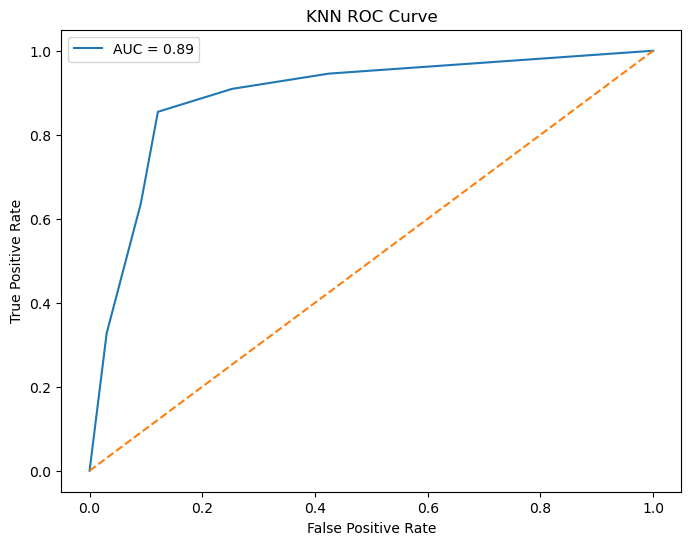

KNN ROC-AUC: 0.8918273645546372


In [63]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability prediction
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)

# AUC
auc_knn = roc_auc_score(y_test, y_prob_knn)

# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f"AUC = {auc_knn:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

print("KNN ROC-AUC:", auc_knn)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    accuracies.append(accuracy)

# Best K
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print("Best K Value:", best_k)
print("Best Accuracy:", best_accuracy)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.xticks(k_values)
plt.show()

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("Final KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Random Forest</b></span>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

rf_model.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance)

plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

print("Random Forest ROC-AUC:", auc_rf)

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Naive Bayes</b></span>

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

In [ ]:
y_pred_nb = nb_model.predict(X_test_scaled)

In [ ]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", accuracy_nb)


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))


print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

In [ ]:

y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

fpr_nb, tpr_nb, thresholds_nb = roc_curve(
    y_test, y_prob_nb
)

auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, label=f"AUC = {auc_nb:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.show()

print("Naive Bayes ROC-AUC:", auc_nb)

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>SVM</b></span>

In [ ]:

from sklearn.svm import SVC
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42)

svm_model.fit(X_train_scaled, y_train)

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

In [ ]:
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

fpr_svm, tpr_svm, thresholds_svm = roc_curve(
    y_test, y_prob_svm
)

auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"AUC = {auc_svm:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

print("SVM ROC-AUC:", auc_svm)

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>AdaBoost</b></span>

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42)
ada_model.fit(X_train, y_train)


In [ ]:
y_pred_ada = ada_model.predict(X_test)

In [ ]:
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", accuracy_ada)


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))


print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

In [ ]:

y_prob_ada = ada_model.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, thresholds_ada = roc_curve(
    y_test, y_prob_ada
)

auc_ada = roc_auc_score(y_test, y_prob_ada)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ada, tpr_ada, label=f"AUC = {auc_ada:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost ROC Curve")
plt.legend()
plt.show()

print("AdaBoost ROC-AUC:", auc_ada)

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>Gradient Boosting</b></span>

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

In [ ]:
y_pred_gb = gb_model.predict(X_test)

In [ ]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", accuracy_gb)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))


print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

In [ ]:

y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, label=f"AUC = {auc_gb:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")
plt.legend()
plt.show()

print("Gradient Boosting ROC-AUC:", auc_gb)

<span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>XGBoost</b></span>

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)


accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

In [ ]:






# 7. ROC Curve & AUC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"AUC = {auc_xgb:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

print("XGBoost ROC-AUC:", auc_xgb)